# FMA Baseline - Log-Mel -> 2D CNN (Version 1)

Goal-1 controlled counterpart to `baseline_mfcc_cnn_v5.ipynb`.
Everything is identical except the input representation:

- MFCC baseline uses 13 MFCC coefficients
- This notebook uses 128 log-mel bands
- Same STFT params: `n_fft=512, hop_length=256`
- Same training recipe: SGD lr=1e-3, 20 epochs, batch size 16

References:
- `MelCNN-MGR/model_training/baseline_mfcc_cnn_v5.ipynb`
- `docs/Final-Project-Proposal.md`


## 1. Imports


In [24]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import os

warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")


Python     : 3.11.14
TensorFlow : 2.15.1


## Device runtime selection (CUDA -> Intel XPU -> CPU)

This notebook prefers acceleration in this order:
1. CUDA GPU (`/GPU:0`)
2. Intel XPU (`/XPU:0`) via ITEX
3. CPU (`/CPU:0`)


## 2. Configuration & Hyperparameters

Set `SUBSET` to `"tiny"`, `"small"`, or `"medium"`.
Set `CLEAR_CACHE = True` to force re-extraction.


In [25]:
# -- Paths ---------------------------------------------------------------------
NOTEBOOK_DIR    = Path().resolve()
MELCNN_DIR      = NOTEBOOK_DIR.parent
WORKSPACE       = MELCNN_DIR.parent

PROCESSED_DIR   = MELCNN_DIR / "data" / "processed"
CACHE_DIR       = MELCNN_DIR / "cache"

# -- Per-run model directory ---------------------------------------------------
MODELS_BASE_DIR = MELCNN_DIR / "models"
RUN_DIR         = None

# -- Subset --------------------------------------------------------------------
SUBSET        = "tiny"   # "tiny" | "small" | "medium" | "large"
CLEAR_CACHE   = False

# -- Audio backend -------------------------------------------------------------
import shutil as _shutil
FFMPEG_AVAILABLE = _shutil.which("ffmpeg") is not None
AUDIO_BACKEND = "ffmpeg" if FFMPEG_AVAILABLE else "librosa"
print(f"[Audio] backend = {AUDIO_BACKEND} (ffmpeg_available={FFMPEG_AVAILABLE})")

# -- Performance knobs ---------------------------------------------------------
NUM_WORKERS   = min(6, (os.cpu_count() or 8))

# -- Audio sanity checks -------------------------------------------------------
MIN_SECONDS   = 1.0
SKIP_SILENT   = False
SILENCE_PEAK  = 1e-4
SILENCE_STD   = 1e-5

# -- Cache layout (per-track) --------------------------------------------------
LOGMEL_CACHE_SHARED = True
LOGMEL_CACHE_DIR = CACHE_DIR / "logmel" / ("shared" if LOGMEL_CACHE_SHARED else SUBSET)

# -- Training hyperparameters --------------------------------------------------
EPOCHS        = 20
BATCH_SIZE    = 16

# -- Log-mel extraction params -------------------------------------------------
SAMPLE_RATE   = 22050
N_MELS        = 128
N_FFT         = 512
HOP_LENGTH    = 256
N_FRAMES      = 2582
LOGMEL_SHAPE  = (N_MELS, N_FRAMES)

# -- Reproducibility seed ------------------------------------------------------
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"[Seed] SEED={SEED} applied to random / numpy / tensorflow")

# -- Global timer --------------------------------------------------------------
import time as _time_module
_T0             = _time_module.perf_counter()
_section_times  = {}

[Audio] backend = ffmpeg (ffmpeg_available=True)
[Seed] SEED=42 applied to random / numpy / tensorflow


In [26]:
_t0 = _time_module.perf_counter()

import platform
import traceback

def _best_effort_set_memory_growth(tf, device_type: str):
    devs = tf.config.list_physical_devices(device_type)
    for d in devs:
        try:
            tf.config.experimental.set_memory_growth(d, True)
        except Exception:
            pass
    return devs

def _smoke_test_matmul(tf, device: str, n: int = 1024) -> tuple[bool, str]:
    try:
        with tf.device(device):
            a = tf.random.normal([n, n])
            b = tf.random.normal([n, n])
            c = tf.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as e:
        return False, repr(e)

def configure_runtime_device(tf):
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf.__version__}")

    try:
        gpus = _best_effort_set_memory_growth(tf, "GPU")
    except Exception:
        gpus = []
    if gpus:
        ok, info = _smoke_test_matmul(tf, "/GPU:0", n=1024)
        if ok:
            return "/GPU:0", "cuda", [d.name for d in gpus], info
        print("CUDA present but failed smoke test ->", info)

    try:
        import intel_extension_for_tensorflow as itex  # noqa: F401
        xpus = _best_effort_set_memory_growth(tf, "XPU")
    except Exception as e:
        xpus = []
        print("ITEX/XPU not available:", repr(e))

    if xpus:
        ok, info = _smoke_test_matmul(tf, "/XPU:0", n=1024)
        if ok:
            return "/XPU:0", "xpu", [d.name for d in xpus], info
        print("XPU present but failed smoke test ->", info)

    return "/CPU:0", "cpu", [], "ok"

RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)

print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
if ACCEL_NAMES:
    print(f"Devices    : {ACCEL_NAMES}")
else:
    print("Devices    : none detected -> CPU fallback")
print(f"Smoke test : {SMOKE_INFO}")

_section_times["2. Device setup"] = _time_module.perf_counter() - _t0
print()
print(f"Device setup : {_section_times['2. Device setup']:.2f}s")


Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1
Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok

Device setup : 0.02s


## 3. Load Manifest Splits


In [27]:
_t0 = _time_module.perf_counter()

def load_manifest_splits(processed_dir: Path, subset: str):
    def _load(name: str) -> pd.DataFrame:
        path = processed_dir / f"{name}_{subset}.parquet"
        if not path.exists():
            msg_lines = [
                f"Manifest parquet not found: {path}",
                "Run build_manifest.py first:",
                "  python MelCNN-MGR/preprocessing/build_manifest.py",
            ]
            raise FileNotFoundError(chr(10).join(msg_lines))
        return pd.read_parquet(path)

    train_df = _load("train")
    val_df   = _load("val")
    test_df  = _load("test")
    return train_df, val_df, test_df

print("Loading manifest parquets ...")
train_df, val_df, test_df = load_manifest_splits(PROCESSED_DIR, SUBSET)

print(f"  train : {len(train_df):>5,} rows")
print(f"  val   : {len(val_df):>5,} rows")
print(f"  test  : {len(test_df):>5,} rows")

all_genres    = sorted(pd.concat([train_df, val_df, test_df])["genre_top"].unique().tolist())
N_CLASSES     = len(all_genres)
GENRE_CLASSES = all_genres
print()
print(f"  Genres ({N_CLASSES}): {GENRE_CLASSES}")

label_enc = LabelEncoder().fit(GENRE_CLASSES)

_section_times["3. Load manifest"] = _time_module.perf_counter() - _t0
print()
print(f"Load manifest : {_section_times['3. Load manifest']:.2f}s")


Loading manifest parquets ...
  train :   925 rows
  val   :   189 rows
  test  :   193 rows

  Genres (15): ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

Load manifest : 0.07s


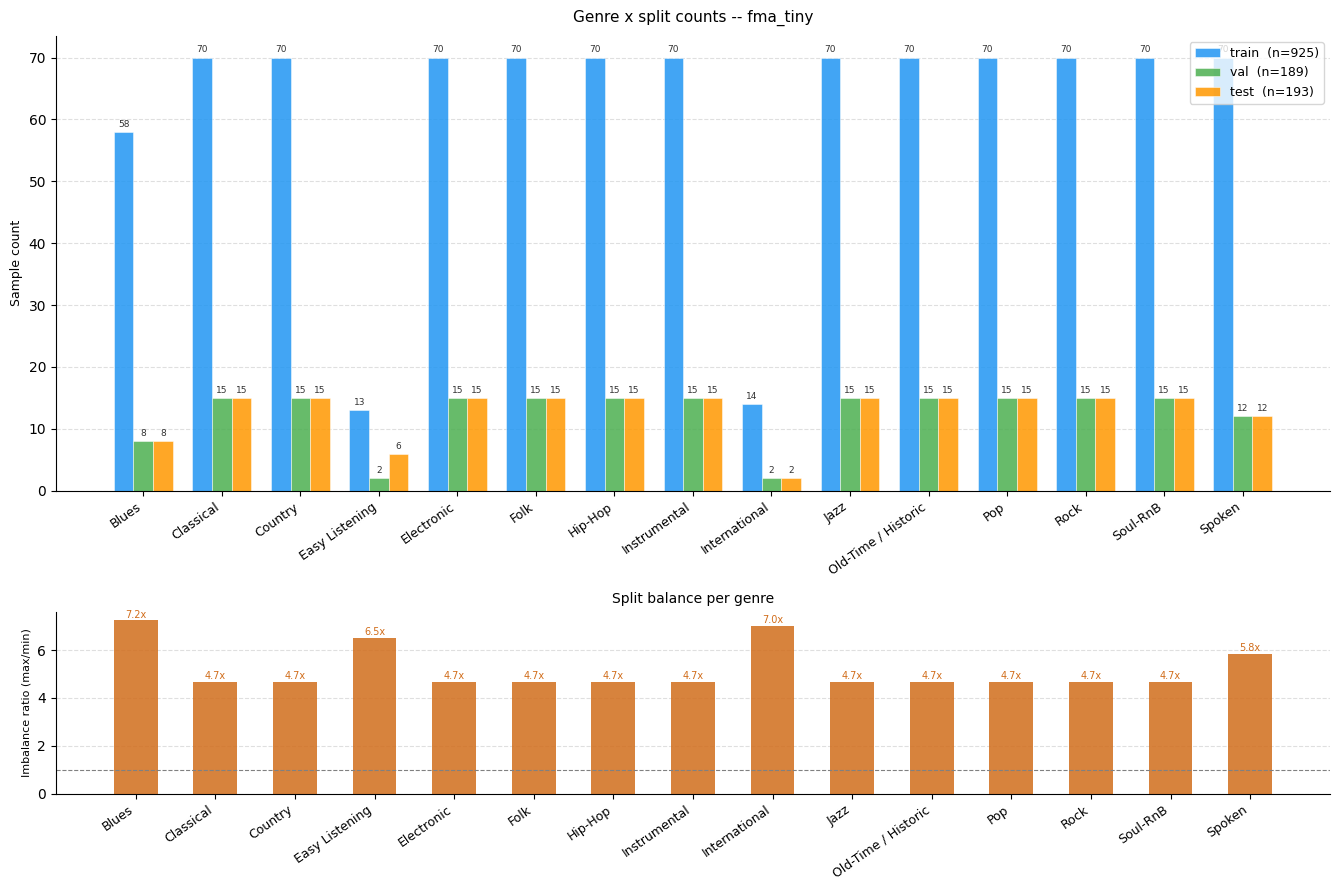

Most imbalanced genre across splits : Blues  (ratio = 7.25x)
-> Significant imbalance detected -- consider class-weighted loss or reporting Macro-F1 as the primary metric.

Genre distribution plot : 0.78s


In [28]:
_t0 = _time_module.perf_counter()

splits      = ["train", "val", "test"]
dfs         = [train_df, val_df, test_df]
split_colors = ["#2196F3", "#4CAF50", "#FF9800"]

genres_sorted = sorted(all_genres)
n_genres      = len(genres_sorted)

counts_matrix = np.array(
    [[df["genre_top"].value_counts().get(g, 0) for df in dfs] for g in genres_sorted],
    dtype=int,
)

row_max   = counts_matrix.max(axis=1).astype(float)
row_min   = np.where(counts_matrix.min(axis=1) == 0, 1, counts_matrix.min(axis=1)).astype(float)
imbalance = row_max / row_min

fig, (ax_bar, ax_imb) = plt.subplots(
    2, 1,
    figsize=(max(12, n_genres * 0.9), 9),
    gridspec_kw={"height_ratios": [3, 1.2]},
)

x       = np.arange(n_genres)
n_grps  = len(splits)
width   = 0.25
offsets = np.linspace(-(n_grps - 1) / 2, (n_grps - 1) / 2, n_grps) * width

for j, (split, color, offset) in enumerate(zip(splits, split_colors, offsets)):
    counts = counts_matrix[:, j]
    bars   = ax_bar.bar(x + offset, counts, width=width,
                        label=f"{split}  (n={counts.sum():,})",
                        color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(cnt),
                ha="center", va="bottom", fontsize=6.5, color="#333333",
            )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_bar.set_ylabel("Sample count", fontsize=9)
ax_bar.set_title(f"Genre x split counts -- fma_{SUBSET}", fontsize=11, pad=10)
ax_bar.legend(fontsize=9, loc="upper right")
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_bar.set_axisbelow(True)

bar_colors = ["#d16d1b" if r > 1.5 else "#159dd3" for r in imbalance]
ax_imb.bar(x, imbalance, color=bar_colors, width=0.55, edgecolor="none", alpha=0.85)
ax_imb.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax_imb.set_xticks(x)
ax_imb.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_imb.set_ylabel("Imbalance ratio (max/min)", fontsize=8)
ax_imb.set_title("Split balance per genre", fontsize=10, pad=6)
for i, (xi, r) in enumerate(zip(x, imbalance)):
    ax_imb.text(xi, r + 0.03, f"{r:.1f}x", ha="center", va="bottom",
                fontsize=7, color="#d16d1b" if r > 1.5 else "#159dd3")
for spine in ["top", "right"]:
    ax_imb.spines[spine].set_visible(False)
ax_imb.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_imb.set_axisbelow(True)

plt.tight_layout()
plt.show()

worst_genre = genres_sorted[int(np.argmax(imbalance))]
worst_ratio = float(imbalance.max())
print(f"Most imbalanced genre across splits : {worst_genre}  (ratio = {worst_ratio:.2f}x)")
if worst_ratio <= 1.05:
    print("-> All genres are near-perfectly balanced across splits.")
elif worst_ratio <= 2.0:
    print("-> Minor imbalance; using class-weighted loss is optional.")
else:
    print("-> Significant imbalance detected -- consider class-weighted loss or reporting Macro-F1 as the primary metric.")

_section_times["3b. Genre plot"] = _time_module.perf_counter() - _t0
print()
print(f"Genre distribution plot : {_section_times['3b. Genre plot']:.2f}s")


## 4. Log-Mel Feature Extraction

Each 30-second clip is loaded at `sr=22050 Hz`, and a 128-band log-mel spectrogram is
computed with `n_fft=512`, `hop_length=256`, yielding a `(128, 2582)` matrix.
Shorter clips are zero-padded; longer ones are truncated.
Results are cached as `.npy` files so subsequent runs skip extraction entirely.

### Corrupt or unreadable tracks

Some tracks in each split may be silently dropped:

* source MP3 cannot be decoded (corrupt file or truncated download)
* decoded audio is too short, empty, or has non-finite samples
* a previously cached `.npy` has the wrong shape or is unreadable

If corrupt `.npy` files are found after loading a cached index, they are deleted and
**re-extracted in the same run** (not deferred to the next execution).
The final "Usable rows" printout at the end of this section shows how many tracks
from each split actually reach the model — compare against the manifest totals to
detect any data-quality losses before interpreting results.


In [29]:
import librosa
import subprocess
import concurrent.futures as _fut


def _track_id_from_path(filepath: Path) -> int:
    try:
        return int(Path(filepath).stem)
    except Exception:
        return abs(hash(str(filepath))) % (10**12)


def _load_audio_ffmpeg(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    cmd = ["ffmpeg", "-v", "error", "-i", str(filepath), "-vn", "-sn", "-dn"]
    if duration is not None:
        cmd += ["-t", str(duration)]
    cmd += ["-ar", str(sr)]
    if mono:
        cmd += ["-ac", "1"]
    cmd += ["-f", "f32le", "pipe:1"]

    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    if proc.returncode != 0:
        err = proc.stderr.decode("utf-8", errors="ignore").strip()
        raise RuntimeError(f"ffmpeg decode failed: {err}")
    y = np.frombuffer(proc.stdout, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError("ffmpeg produced empty output")
    return y


def _load_audio_simple(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    if AUDIO_BACKEND == "ffmpeg":
        return _load_audio_ffmpeg(filepath, sr=sr, mono=mono, duration=duration)
    y, _sr = librosa.load(str(filepath), sr=sr, mono=mono, duration=duration)
    return y.astype(np.float32, copy=False)


def _sanity_check_audio(y: np.ndarray, sr: int) -> tuple[bool, str]:
    if y is None or len(y) == 0:
        return False, "empty_audio"
    if not np.isfinite(y).all():
        return False, "non_finite_samples"
    if len(y) < int(MIN_SECONDS * sr):
        return False, f"too_short(<{MIN_SECONDS}s)"
    if SKIP_SILENT:
        peak = float(np.max(np.abs(y)))
        st   = float(np.std(y))
        if peak < SILENCE_PEAK or st < SILENCE_STD:
            return False, "near_silent"
    return True, ""


def _logmel_fixed_shape(y: np.ndarray) -> np.ndarray:
    S = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    logmel = np.log1p(S)
    out = np.zeros(LOGMEL_SHAPE, dtype=np.float32)
    n = min(logmel.shape[1], N_FRAMES)
    out[:, :n] = logmel[:, :n].astype(np.float32, copy=False)
    return out


def _is_valid_npy(path: Path, expected_shape: tuple) -> bool:
    """Return True only if the .npy file loads cleanly and has the expected shape."""
    try:
        arr = np.load(str(path), mmap_mode='r')
        return arr.shape == expected_shape
    except Exception:
        return False


def _process_one_track(task: tuple) -> dict:
    filepath_str, split_name, genre_top, track_id, logmel_cache_dir = task
    filepath = Path(filepath_str)
    logmel_path = Path(logmel_cache_dir) / f"{track_id}.npy"

    _corrupt_deleted = False

    if logmel_path.exists():
        if _is_valid_npy(logmel_path, LOGMEL_SHAPE):
            return {
                "track_id": track_id,
                "filepath": filepath_str,
                "split": split_name,
                "genre_top": genre_top,
                "logmel_path": str(logmel_path),
                "status": "cached",
                "reason": "",
                "corrupt_deleted": False,
            }
        # Corrupt or wrong-shape file — log, delete, then fall through to re-extract
        print(f"[WARN] Corrupt/invalid .npy deleted, will re-extract: {logmel_path}", flush=True)
        _corrupt_deleted = True
        try:
            logmel_path.unlink()
        except Exception:
            pass

    try:
        y = _load_audio_simple(filepath, sr=SAMPLE_RATE, mono=True, duration=30.0)
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "logmel_path": "",
            "status": "skipped",
            "reason": f"decode_fail:{type(exc).__name__}",
            "corrupt_deleted": _corrupt_deleted,
        }

    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "logmel_path": "",
            "status": "skipped",
            "reason": reason,
            "corrupt_deleted": _corrupt_deleted,
        }

    try:
        logmel = _logmel_fixed_shape(y)
        logmel_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(logmel_path, logmel)
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "logmel_path": str(logmel_path),
            "status": "ok",
            "reason": "",
            "corrupt_deleted": _corrupt_deleted,
        }
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "logmel_path": "",
            "status": "skipped",
            "reason": f"logmel_fail:{type(exc).__name__}",
            "corrupt_deleted": _corrupt_deleted,
        }


def build_logmel_index(
    split_df: pd.DataFrame,
    split_name: str,
    cache_dir: Path,
    num_workers: int,
    clear_cache: bool = False,
) -> pd.DataFrame:
    cache_dir.mkdir(parents=True, exist_ok=True)
    index_path = CACHE_DIR / f"logmel_index_{split_name}_{SUBSET}.parquet"

    if clear_cache:
        if cache_dir.exists():
            import shutil
            shutil.rmtree(cache_dir, ignore_errors=True)
        if index_path.exists():
            index_path.unlink()

    if index_path.exists():
        print(f"  [{split_name}] Loading log-mel index from cache ...")
        return pd.read_parquet(index_path)

    print(f"  [{split_name}] Building log-mel cache with {num_workers} workers ...")
    tasks = []
    for row in split_df.itertuples(index=False):
        fp = getattr(row, "filepath") if hasattr(row, "filepath") else row[split_df.columns.get_loc("filepath")]
        gt = getattr(row, "genre_top") if hasattr(row, "genre_top") else row[split_df.columns.get_loc("genre_top")]
        tid = _track_id_from_path(fp)
        tasks.append((str(fp), split_name, str(gt), int(tid), str(cache_dir)))

    results = []
    skipped = 0
    t0 = time.time()

    with _fut.ProcessPoolExecutor(max_workers=num_workers) as ex:
        for i, res in enumerate(ex.map(_process_one_track, tasks, chunksize=32), start=1):
            if res.get("corrupt_deleted"):
                print(f"  [WARN] Corrupt cache re-extracted: {Path(res['filepath']).name}  (track_id={res['track_id']})")
            results.append(res)
            if res["status"] == "skipped":
                skipped += 1
            if i % 100 == 0 or i == len(tasks):
                elapsed = time.time() - t0
                print(f"    {i}/{len(tasks)}  skipped={skipped}  -- {elapsed:.0f}s elapsed")

    index_df = pd.DataFrame(results)
    index_df.to_parquet(index_path, index=False)
    print(f"    Saved index -> {index_path}")
    return index_df


In [30]:

_t0 = _time_module.perf_counter()

print("Building/loading log-mel per-track cache + index parquets ...")
print()

train_index = build_logmel_index(train_df, "training",   LOGMEL_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
val_index   = build_logmel_index(val_df,   "validation", LOGMEL_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
test_index  = build_logmel_index(test_df,  "test",       LOGMEL_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)

def _usable(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["status"].isin(["ok", "cached"])].reset_index(drop=True)

def _purge_corrupt(index_df: pd.DataFrame, expected_shape: tuple) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Check each cached .npy; delete bad files.
    Returns (clean_df, corrupt_df) — corrupt_df rows need re-extraction."""
    if index_df.empty:
        return index_df, index_df
    ok_mask = np.array([_is_valid_npy(Path(p), expected_shape) for p in index_df["logmel_path"]], dtype=bool)
    n_corrupt = int((~ok_mask).sum())
    for p in index_df.loc[~ok_mask, "logmel_path"]:
        print(f"  [WARN] Corrupt/missing — will re-extract: {p}")
        try:
            Path(p).unlink(missing_ok=True)
        except Exception:
            pass
    if n_corrupt:
        print(f"  Found {n_corrupt} corrupt/missing entries — re-extracting now ...")
    return index_df[ok_mask].reset_index(drop=True), index_df[~ok_mask].reset_index(drop=True)


def _reextract_corrupt(
    corrupt_df: pd.DataFrame,
    full_index_df: pd.DataFrame,
    index_path: Path,
) -> pd.DataFrame:
    """Re-extract tracks that were purged, update the index parquet, return repaired usable rows."""
    if len(corrupt_df) == 0:
        return corrupt_df
    tasks = [
        (row["filepath"], row["split"], row["genre_top"], int(row["track_id"]), str(LOGMEL_CACHE_DIR))
        for _, row in corrupt_df.iterrows()
    ]
    results, n_ok, n_skip = [], 0, 0
    with _fut.ProcessPoolExecutor(max_workers=NUM_WORKERS) as ex:
        for i, res in enumerate(ex.map(_process_one_track, tasks, chunksize=16), start=1):
            results.append(res)
            if res["status"] in ("ok", "cached"):
                n_ok += 1
            else:
                n_skip += 1
            if i % 50 == 0 or i == len(tasks):
                print(f"    re-extract {i}/{len(tasks)}  ok={n_ok}  skipped={n_skip}")
    print(f"  Re-extraction complete: {n_ok} ok, {n_skip} permanently skipped")
    repaired_df = pd.DataFrame(results)
    # Persist updated index — replace old corrupt rows with fresh results
    updated_full = (
        pd.concat([full_index_df, repaired_df])
        .drop_duplicates(subset=["track_id"], keep="last")
        .reset_index(drop=True)
    )
    updated_full.to_parquet(index_path, index=False)
    return repaired_df[repaired_df["status"].isin(["ok", "cached"])].reset_index(drop=True)


def _purge_and_repair(full_index: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Purge corrupt cache entries and immediately re-extract them in the same run."""
    index_path = CACHE_DIR / f"logmel_index_{split_name}_{SUBSET}.parquet"
    clean_df, corrupt_df = _purge_corrupt(_usable(full_index), LOGMEL_SHAPE)
    repaired_df = _reextract_corrupt(corrupt_df, full_index, index_path)
    return pd.concat([clean_df, repaired_df]).reset_index(drop=True)


train_index_u = _purge_and_repair(train_index, "training")
val_index_u   = _purge_and_repair(val_index,   "validation")
test_index_u  = _purge_and_repair(test_index,  "test")

print("Usable rows:")
print(f"  train: {len(train_index_u):,} / {len(train_index):,}")
print(f"  val  : {len(val_index_u):,} / {len(val_index):,}")
print(f"  test : {len(test_index_u):,} / {len(test_index):,}")

_section_times["4. Log-mel extraction"] = _time_module.perf_counter() - _t0
print()
print(f"Log-mel cache+index : {_section_times['4. Log-mel extraction']:.2f}s")

Building/loading log-mel per-track cache + index parquets ...

  [training] Building log-mel cache with 6 workers ...
    100/925  skipped=100  -- 4s elapsed
    200/925  skipped=200  -- 7s elapsed
    300/925  skipped=300  -- 7s elapsed
    400/925  skipped=400  -- 11s elapsed
    500/925  skipped=500  -- 11s elapsed
    600/925  skipped=600  -- 14s elapsed
    700/925  skipped=700  -- 14s elapsed
    800/925  skipped=800  -- 17s elapsed
    900/925  skipped=900  -- 17s elapsed
    925/925  skipped=925  -- 17s elapsed
    Saved index -> /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_index_training_tiny.parquet
  [validation] Building log-mel cache with 6 workers ...
    100/189  skipped=100  -- 4s elapsed
    189/189  skipped=189  -- 4s elapsed
    Saved index -> /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_index_validation_tiny.parquet
  [test] Building log-mel cache with 6 workers ...
    100/193  skipped=100  -- 4s e

In [31]:
_t0 = _time_module.perf_counter()

idx_row = 0
row = train_index_u.iloc[idx_row]
logmel = np.load(row["logmel_path"])
genre = row["genre_top"]
tid = row["track_id"]

fig, ax = plt.subplots(figsize=(14, 5))
img = ax.imshow(logmel, aspect="auto", origin="lower",
                extent=[0, N_FRAMES * HOP_LENGTH / SAMPLE_RATE, 0, N_MELS],
                cmap="magma")
ax.set_title(f"Sample log-mel spectrogram - genre: {genre}  (track_id={tid})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mel band")
plt.colorbar(img, ax=ax, label="log(1 + power)")
plt.tight_layout()
plt.show()

_section_times["4b. Log-mel plot"] = _time_module.perf_counter() - _t0
print(f"Log-mel sample plot : {_section_times['4b. Log-mel plot']:.2f}s")


IndexError: single positional indexer is out-of-bounds

## 5. Preprocessing


In [ ]:
_t0 = _time_module.perf_counter()

# -- Label encoding ------------------------------------------------------------
train_index_u["label_int"] = label_enc.transform(train_index_u["genre_top"].to_numpy())
val_index_u["label_int"]   = label_enc.transform(val_index_u["genre_top"].to_numpy())
test_index_u["label_int"]  = label_enc.transform(test_index_u["genre_top"].to_numpy())

# -- Compute per-band mean/std over TRAIN (streaming, no big array in RAM) -----
def compute_train_stats(index_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    sum_c   = np.zeros((N_MELS,), dtype=np.float64)
    sumsq_c = np.zeros((N_MELS,), dtype=np.float64)
    count = 0

    for i, p in enumerate(index_df["logmel_path"]):
        x = np.load(p)
        sum_c   += x.sum(axis=1)
        sumsq_c += (x * x).sum(axis=1)
        count   += x.shape[1]
        if (i + 1) % 2000 == 0:
            print(f"  stats pass: {i+1}/{len(index_df)}")

    mean = sum_c / max(1, count)
    var  = (sumsq_c / max(1, count)) - mean**2
    std  = np.sqrt(np.maximum(var, 1e-12))

    mu  = mean.reshape((1, N_MELS, 1, 1)).astype(np.float32)
    sig = std.reshape((1, N_MELS, 1, 1)).astype(np.float32)
    return mu, sig

print("Computing training mean/std (streaming) ...")
mu, std = compute_train_stats(train_index_u)
print(f"mu shape={mu.shape}, std shape={std.shape}")

# -- tf.data input pipeline ----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
mu_tf  = tf.constant(mu, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

def _np_load_logmel(path_bytes):
    path = path_bytes.decode("utf-8")
    x = np.load(path).astype(np.float32, copy=False)
    x = x[..., np.newaxis]
    return x

def make_dataset(index_df: pd.DataFrame, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    paths  = index_df["logmel_path"].to_numpy(dtype=str)
    labels = index_df["label_int"].to_numpy(dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10_000), seed=SEED, reshuffle_each_iteration=True)

    def _load_and_norm(path, y):
        x = tf.numpy_function(_np_load_logmel, [path], Tout=tf.float32)
        x.set_shape((*LOGMEL_SHAPE, 1))
        x = (x - mu_tf[0]) / std_tf[0]
        y_oh = tf.one_hot(y, N_CLASSES)
        return x, y_oh

    ds = ds.map(_load_and_norm, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_index_u, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_index_u,   BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_index_u,  BATCH_SIZE, shuffle=False)

print("Datasets ready:")
print(f"  train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  val   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  test  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

_section_times["5. Preprocessing"] = _time_module.perf_counter() - _t0
print(f"\nPreprocessing : {_section_times['5. Preprocessing']:.2f}s")


## 6. Build the CNN Model


In [ ]:
_t0 = _time_module.perf_counter()

def build_model(n_classes: int) -> keras.Model:
    inputs = keras.Input(shape=(*LOGMEL_SHAPE, 1), name="logmel")

    x = layers.Conv2D(3,  (N_MELS, 10), strides=(1, 4), padding="valid", activation="relu", name="conv1")(inputs)
    x = layers.Conv2D(15, (1,  10), strides=(1, 4), padding="valid", activation="relu", name="conv2")(x)
    x = layers.Conv2D(65, (1,  10), strides=(1, 4), padding="valid", activation="relu", name="conv3")(x)
    x = layers.Flatten(name="flatten")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="fc_out")(x)

    return keras.Model(inputs, outputs, name="logmel_2dcnn_baseline")

with tf.device(RUNTIME_DEVICE):
    model = build_model(N_CLASSES)

model.summary()

_section_times["6. Build model"] = _time_module.perf_counter() - _t0
print(f"\nBuild model : {_section_times['6. Build model']:.2f}s")


## 7. Compile & Train


In [ ]:
import datetime as _dt
import json as _json

_t0 = _time_module.perf_counter()

_run_ts = _dt.datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_BASE_DIR / f"baseline_logmel-cnn-{_run_ts}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run directory : {RUN_DIR}")

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

print(f"Training on {RUNTIME_DEVICE}  |  epochs={EPOCHS}, batch_size={BATCH_SIZE}\n")

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
    )

best = min(range(len(history.history["val_loss"])), key=lambda i: history.history["val_loss"][i])
print(f"\nBest epoch : {best + 1} / {EPOCHS}")
for k in ["loss", "accuracy", "val_loss", "val_accuracy"]:
    print(f"  {k:<16}: {history.history[k][best]:.4f}")

_section_times["7. Compile & train"] = _time_module.perf_counter() - _t0
print(f"\nCompile & train : {_section_times['7. Compile & train']:.1f}s  ({_section_times['7. Compile & train']/EPOCHS:.1f}s per epoch)")

model_path = RUN_DIR / "baseline_logmel_cnn.keras"
model.save(str(model_path))
print(f"Model saved  -> {model_path}")

_hist    = history.history
_n_ep    = len(_hist["loss"])
_t_train = _section_times["7. Compile & train"]

_summary_lines = []
model.summary(print_fn=lambda l: _summary_lines.append(l))

_report = {
    "run_id":       f"logmel-cnn-{_run_ts}",
    "subset":       SUBSET,
    "generated_at": _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_file":   model_path.name,
    "feature_type": "logmel",
    "config": {
        "device":        RUNTIME_DEVICE,
        "audio_backend": AUDIO_BACKEND,
        "num_workers":   NUM_WORKERS,
        "logmel_extraction": {
            "sample_rate":  SAMPLE_RATE,
            "n_mels":       N_MELS,
            "n_fft":        N_FFT,
            "hop_length":   HOP_LENGTH,
            "n_frames":     N_FRAMES,
            "logmel_shape": list(LOGMEL_SHAPE),
            "log_compress": "log1p",
            "cache_shared": LOGMEL_CACHE_SHARED,
        },
        "training": {
            "epochs":     EPOCHS,
            "batch_size": BATCH_SIZE,
            "optimizer":  "SGD",
            "lr":         1e-3,
            "loss":       "categorical_crossentropy",
        },
    },
    "dataset": {
        "n_classes":     N_CLASSES,
        "genres":        GENRE_CLASSES,
        "train_samples": len(train_index_u),
        "val_samples":   len(val_index_u),
        "test_samples":  len(test_index_u),
    },
    "model_architecture": {
        "name":         model.name,
        "total_params": model.count_params(),
        "summary":      "\n".join(_summary_lines),
    },
    "training_history": {
        "epochs": [
            {
                "epoch":        i + 1,
                "loss":         float(_hist["loss"][i]),
                "accuracy":     float(_hist["accuracy"][i]),
                "val_loss":     float(_hist["val_loss"][i]),
                "val_accuracy": float(_hist["val_accuracy"][i]),
            }
            for i in range(_n_ep)
        ],
        "best_epoch": {
            "epoch":        best + 1,
            "loss":         float(_hist["loss"][best]),
            "accuracy":     float(_hist["accuracy"][best]),
            "val_loss":     float(_hist["val_loss"][best]),
            "val_accuracy": float(_hist["val_accuracy"][best]),
        },
        "timing_seconds":    round(_t_train, 2),
        "seconds_per_epoch": round(_t_train / _n_ep, 2),
    },
    "evaluation": None,
}

REPORT_PATH = RUN_DIR / f"run_report_{SUBSET}.json"
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Run report   -> {REPORT_PATH}")


## 8. Training History


In [ ]:
_t0 = _time_module.perf_counter()

hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

ax_acc.plot(epochs_range, hist["accuracy"],     label="Train",      linewidth=2)
ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_acc.spines[spine].set_visible(False)

ax_loss.plot(epochs_range, hist["loss"],     label="Train",      linewidth=2)
ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", linewidth=2, linestyle="--")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Categorical cross-entropy")
ax_loss.legend()
ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_loss.spines[spine].set_visible(False)

fig.suptitle("Training history -- Log-Mel 2D CNN baseline", fontsize=13)
plt.tight_layout()
plt.show()

final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]
print(f"Final train accuracy : {final_train_acc:.4f}  ({final_train_acc:.2%})")
print(f"Final val   accuracy : {final_val_acc:.4f}  ({final_val_acc:.2%})")

_section_times["8. Training history plot"] = _time_module.perf_counter() - _t0
print(f"\nTraining history plot : {_section_times['8. Training history plot']:.2f}s")


## 9. Evaluate the Model


In [ ]:
import json as _json

_t0 = _time_module.perf_counter()


def eval_dataset(model, ds: tf.data.Dataset, genre_classes, split_label: str):
    # ── Cost (aggregate loss over the full split) ──────────────────────────────
    # model.evaluate() runs the compiled loss (CategoricalCrossentropy) over
    # every batch in `ds` and returns the mean — this is the "cost" for the split.
    eval_results = model.evaluate(ds, verbose=0, return_dict=True)
    cost = float(eval_results.get("loss", float("nan")))

    # ── Predictions for accuracy / F1 / confusion matrix ─────────────────────
    y_true, y_pred = [], []
    for xb, yb in ds:
        pred = model(xb, training=False).numpy()
        y_pred.append(np.argmax(pred, axis=1))
        y_true.append(np.argmax(yb.numpy(), axis=1))
    y_true = np.concatenate(y_true) if y_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(y_pred) if y_pred else np.array([], dtype=np.int64)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cr_text  = classification_report(y_true, y_pred, target_names=genre_classes, zero_division=0)
    cr_dict  = classification_report(y_true, y_pred, target_names=genre_classes, zero_division=0, output_dict=True)
    block = (
        f"\n{'='*60}\n {split_label}\n{'='*60}\n"
        f"  Cost     : {cost:.4f}  (CategoricalCrossentropy)\n"
        f"  Accuracy : {acc:.4f}  ({acc:.2%})\n"
        f"  Macro-F1 : {macro_f1:.4f}\n\n"
        f"Per-genre classification report:\n{cr_text}"
    )
    print(block)

    per_genre = {
        g: {k: round(float(v), 4) for k, v in cr_dict[g].items()}
        for g in genre_classes
        if g in cr_dict
    }
    metrics = {
        "cost":      round(cost, 4),
        "accuracy":  round(float(acc), 4),
        "macro_f1":  round(float(macro_f1), 4),
        "per_genre": per_genre,
    }
    return block, y_true, y_pred, metrics


with tf.device(RUNTIME_DEVICE):
    train_block, y_train_true, y_train_pred, train_metrics = eval_dataset(model, train_ds, GENRE_CLASSES, "TRAIN SET")
    val_block,   y_val_true,   y_val_pred,   val_metrics   = eval_dataset(model, val_ds,   GENRE_CLASSES, "VALIDATION SET")
    test_block,  y_test_true,  y_test_pred,  test_metrics  = eval_dataset(model, test_ds,  GENRE_CLASSES, "TEST SET")

_section_times["9. Evaluation"] = _time_module.perf_counter() - _t0
print(f"\nEvaluation : {_section_times['9. Evaluation']:.2f}s")

# ── Cost summary across splits ─────────────────────────────────────────────────
print("\nCost summary (CategoricalCrossentropy):")
for label, m in [("train", train_metrics), ("val  ", val_metrics), ("test ", test_metrics)]:
    print(f"  {label}  cost={m['cost']:.4f}  acc={m['accuracy']:.4f}  macro-f1={m['macro_f1']:.4f}")

_report = _json.loads(REPORT_PATH.read_text())
_report["evaluation"] = {
    "timing_seconds": round(_section_times["9. Evaluation"], 2),
    "splits": {
        "train":      train_metrics,
        "validation": val_metrics,
        "test":       test_metrics,
    },
}
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Report updated -> {REPORT_PATH}")


In [ ]:
_t0 = _time_module.perf_counter()

cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRE_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion matrix -- test set (log-mel)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

_section_times["9b. Confusion matrix"] = _time_module.perf_counter() - _t0
print(f"Confusion matrix : {_section_times['9b. Confusion matrix']:.2f}s")


## 10. Predict on a New Audio Sample


In [ ]:
_t0 = _time_module.perf_counter()

INFER_PATH = "../../FMA/fma_medium/000/000002.mp3"

if INFER_PATH is None:
    rng_idx    = np.random.randint(len(test_df))
    INFER_PATH = Path(test_df.iloc[rng_idx]["filepath"])
    true_genre = test_df.iloc[rng_idx]["genre_top"]
    print(f"Using test sample: {INFER_PATH.name}  (true genre: {true_genre})")
else:
    INFER_PATH = Path(INFER_PATH)
    true_genre = "?"

try:
    y = _load_audio_simple(INFER_PATH, sr=SAMPLE_RATE, mono=True, duration=30.0)
    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        raise ValueError(f"sanity_check_failed:{reason}")
    logmel = _logmel_fixed_shape(y)
except Exception as exc:
    print(f"Could not load/extract log-mel: {exc}")
    logmel = None

if logmel is not None:
    x_infer = ((logmel[np.newaxis, ..., np.newaxis] - mu) / std).astype(np.float32)

    probs      = model.predict(x_infer, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_genre = GENRE_CLASSES[pred_idx]
    confidence = float(probs[pred_idx])

    print(f"\nPredicted genre : {pred_genre}  (confidence: {confidence:.2%})")
    print(f"True genre      : {true_genre}")

    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["steelblue" if g != pred_genre else "tomato" for g in GENRE_CLASSES]
    ax.barh(GENRE_CLASSES, probs, color=colors)
    ax.set_xlabel("Probability")
    ax.set_title(f"Genre probabilities -- {INFER_PATH.name}")
    ax.axvline(1 / N_CLASSES, color="grey", linestyle="--", linewidth=0.8, label=f"Chance ({1/N_CLASSES:.2%})")
    ax.legend(fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

_section_times["10. Inference"] = _time_module.perf_counter() - _t0
print(f"\nInference : {_section_times['10. Inference']:.2f}s")


---

## Runtime Summary


In [ ]:
_total = _time_module.perf_counter() - _T0

SEP = "=" * 52
print(SEP)
print("  Runtime summary")
print(SEP)
for section, elapsed in _section_times.items():
    bar_len  = max(1, int(elapsed / _total * 30))
    bar      = "█" * bar_len
    pct      = elapsed / _total * 100
    mins, secs = divmod(elapsed, 60)
    time_str = f"{int(mins)}m {secs:04.1f}s" if mins else f"{elapsed:6.1f}s"
    print(f"  {section:<28}  {time_str:>9}  {pct:5.1f}%  {bar}")

print(SEP)
mins_total, secs_total = divmod(_total, 60)
total_str = f"{int(mins_total)}m {secs_total:04.1f}s" if mins_total else f"{_total:.1f}s"
print(f"  {'TOTAL':<28}  {total_str:>9}")
print(SEP)
